In [8]:
# ======================================================
# 🧩 Preprocessing for Flight Delay Classification (v3)
# ======================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from category_encoders import TargetEncoder
from imblearn.combine import SMOTEENN


In [9]:
# Load cleaned dataset
df = pd.read_csv("../Data/final_clean_data.csv")

selected_columns = [
    "MONTH","DAY_OF_MONTH","DAY_OF_WEEK",
    "OP_UNIQUE_CARRIER","ORIGIN","DEST",
    "CRS_DEP_TIME","CRS_ARR_TIME",
    "CRS_ELAPSED_TIME","DISTANCE",
    "HourlyDewPointTemperature","HourlyDryBulbTemperature",
    "HourlyRelativeHumidity","HourlyVisibility","HourlyWindSpeed",
    "DEP_DEL15"
]

df_classifi = df[selected_columns].copy()
print("✅ Loaded data shape:", df_classifi.shape)
df_classifi.head()


✅ Loaded data shape: (45155, 16)


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,OP_UNIQUE_CARRIER,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyVisibility,HourlyWindSpeed,DEP_DEL15
0,4,1,2,AA,GEG,PHX,6.53,9.33,168.0,1020.0,33.0,36.0,89.0,5.0,10.0,0.0
1,4,1,2,AA,GEG,PHX,15.45,18.12,160.0,1020.0,33.0,45.0,63.0,10.0,10.0,1.0
2,4,1,2,AA,SEA,CLT,7.33,15.32,299.0,2279.0,37.0,43.0,80.0,10.0,6.0,0.0
3,4,1,2,AA,SEA,CLT,13.83,21.83,300.0,2279.0,41.0,49.0,74.0,10.0,6.0,0.0
4,4,1,2,AA,SEA,CLT,22.00,6.00,300.0,2279.0,41.0,45.0,86.0,10.0,7.0,0.0


In [10]:
# ======================================================
# 🧹 Remove outliers on selected numerical features
# ======================================================

num_cols = [
    "DISTANCE","CRS_ELAPSED_TIME",
    "HourlyDryBulbTemperature","HourlyDewPointTemperature",
    "HourlyWindSpeed","HourlyVisibility"
]

def remove_outliers_iqr(df, cols):
    df_clean = df.copy()
    for col in cols:
        Q1, Q3 = df_clean[col].quantile([0.25, 0.75])
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

before = df_classifi.shape[0]
df_classifi = remove_outliers_iqr(df_classifi, num_cols)
after = df_classifi.shape[0]
print(f"✅ Removed {before - after} outlier rows (Remaining: {after})")


✅ Removed 4699 outlier rows (Remaining: 40456)


In [11]:
# ======================================================
# 🧠 Feature Engineering
# ======================================================

# 1️⃣ TIME_OF_DAY grouping
def time_of_day(hour):
    if 5 <= hour < 9:
        return "morning_peak"
    elif 9 <= hour < 15:
        return "midday"
    elif 15 <= hour < 19:
        return "evening_peak"
    else:
        return "night"

df_classifi["TIME_OF_DAY"] = df_classifi["CRS_DEP_TIME"].apply(time_of_day)

# 2️⃣ TEMP_DIFF
df_classifi["TEMP_DIFF"] = (
    df_classifi["HourlyDryBulbTemperature"] - df_classifi["HourlyDewPointTemperature"]
)

# 3️⃣ WEATHER_SEVERITY
df_classifi["WEATHER_SEVERITY"] = (
    (df_classifi["HourlyWindSpeed"]/10) +
    (100 - df_classifi["HourlyVisibility"])/20 +
    (df_classifi["HourlyRelativeHumidity"]/50)
)

# 4️⃣ ROUTE
df_classifi["ROUTE"] = df_classifi["ORIGIN"] + "_" + df_classifi["DEST"]

# 5️⃣ SEASON
def season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"
df_classifi["SEASON"] = df_classifi["MONTH"].apply(season)

# 6️⃣ IS_WEEKEND, IS_PEAK_HOUR
df_classifi["IS_WEEKEND"] = df_classifi["DAY_OF_WEEK"].isin([6,7]).astype(int)
df_classifi["IS_PEAK_HOUR"] = df_classifi["CRS_DEP_TIME"].apply(lambda x: 1 if 7<=x<=9 or 16<=x<=19 else 0)

print("✅ Feature Engineering completed. Shape:", df_classifi.shape)


✅ Feature Engineering completed. Shape: (40456, 23)


In [12]:
# ======================================================
# 🔢 Encode categorical variables
# ======================================================

cat_cols = ["OP_UNIQUE_CARRIER", "ORIGIN", "DEST", "ROUTE", "SEASON", "TIME_OF_DAY"]
te = TargetEncoder(cols=cat_cols)
df_classifi = te.fit_transform(df_classifi, df_classifi["DEP_DEL15"])

print("✅ Target Encoding done. Current shape:", df_classifi.shape)


✅ Target Encoding done. Current shape: (40456, 23)


In [13]:
from sklearn.model_selection import train_test_split

X = df_classifi.drop(columns=["DEP_DEL15"])
y = df_classifi["DEP_DEL15"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Cân bằng để kiểm tra nhanh (chưa cần lưu)
smenn = SMOTEENN(random_state=42)
X_res, y_res = smenn.fit_resample(X_scaled, y)

print("Before:", np.bincount(y))
print("After :", np.bincount(y_res))


Before: [35709  4747]
After : [23263 31343]


C:\Users\PC\AppData\Local\Temp\ipykernel_32424\434296989.py:13: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Before:", np.bincount(y))
C:\Users\PC\AppData\Local\Temp\ipykernel_32424\434296989.py:14: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("After :", np.bincount(y_res))


In [14]:
# ======================================================
# 💾 Save preprocessed dataset (v3)
# ======================================================

output_path = "../Data/final_classification_ready_v3.csv"
df_classifi.to_csv(output_path, index=False)

print("✅ Saved preprocessed dataset to:", output_path)
print("Final shape:", df_classifi.shape)


✅ Saved preprocessed dataset to: ../Data/final_classification_ready_v3.csv
Final shape: (40456, 23)


DEP_DEL15                    1.000000
OP_UNIQUE_CARRIER            0.154301
ROUTE                        0.140164
TIME_OF_DAY                  0.138561
DEST                         0.121724
CRS_DEP_TIME                 0.114502
ORIGIN                       0.077605
MONTH                        0.069050
SEASON                       0.067125
HourlyDryBulbTemperature     0.056521
HourlyDewPointTemperature    0.050683
DISTANCE                     0.045867
CRS_ELAPSED_TIME             0.044128
CRS_ARR_TIME                 0.043245
HourlyWindSpeed              0.032820
Name: DEP_DEL15, dtype: float64


C:\Users\PC\AppData\Local\Temp\ipykernel_32424\106565568.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.head(15), y=corr.head(15).index, palette="coolwarm")


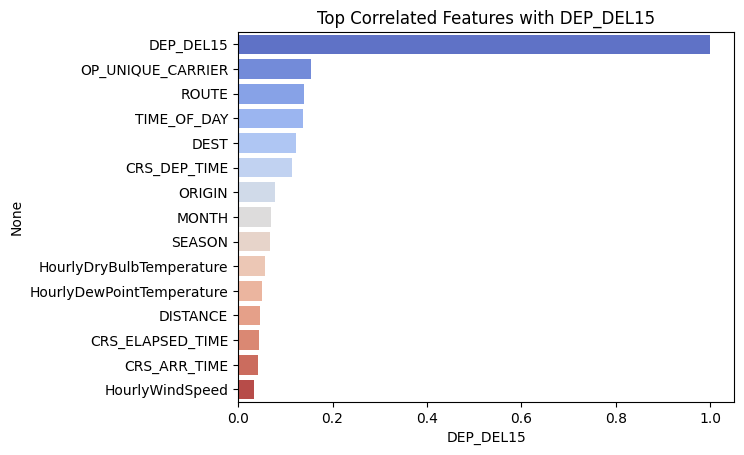

In [15]:
# ======================================================
# 🔍 Check correlations with target
# ======================================================
corr = df_classifi.corr(numeric_only=True)["DEP_DEL15"].sort_values(ascending=False)
print(corr.head(15))
sns.barplot(x=corr.head(15), y=corr.head(15).index, palette="coolwarm")
plt.title("Top Correlated Features with DEP_DEL15")
plt.show()
